In [1]:
import matplotlib.pyplot as plt
import numpy as np
from gsfit_rs.analytic_grad_shafranov.guazzotto_freidberg import Configuration
from gsfit_rs.analytic_grad_shafranov.guazzotto_freidberg import GuazzottoFreidberg
from gsfit_rs.imas import equilibrium_paths as ep

In [2]:
# %matplotlib inline
# %matplotlib widget

In [3]:
"""Example 17 - Forward solves of the Guazzotto-Freidberg analytic equilibrium: FreeGSNKE and GSFit.

1. Solve the up-down symmetric *double-null* spherical tokamak of Guazzotto & Freidberg (GF),
   J. Plasma Phys. 87 (2021) 905870303, exactly as example 14 does, and fit the PF-coil currents on
   the boundary of its grid which reproduce its vacuum field.
2. Forward solve with FreeGSNKE, from the GF coil currents, the shapes of GF's p' and ff', and GF's plasma current.
3. Forward solve with GSFit, from the same inputs, using Picard iterations with the magnetic axis
   supplied (which lets GSFit's vertical feedback hold the plasma). The run without it is commented out:
   by symmetry the fitted delta_z is exactly 0, so it follows the same path.
4. Forward solve with GSFit using Picard iterations with Anderson mixing, again with the magnetic axis supplied: each new state is
   the combination of the last few iterates which best cancels their residuals.
5. Forward solve with GSFit using Newton-Krylov.
6. Forward solve with GSFit using Newton-Picard, the recursive projection method (RPM): Newton's method in the few
   directions in which Picard converges slowly or diverges, and Picard everywhere else.
7. Compare how the stored energy, energy_mhd, converges with iteration in 2 to 5. Newton-Picard (6) is printed, but not plotted.

All three codes hold the shapes of p' and ff' fixed, and scale both by one common amplitude, which is
set by the plasma current.
"""

import math

# --- Dimensionless shape / profile (GF Fig. 7 double-null spherical tokamak) ---
eps = 0.75  # inverse aspect ratio a / r_geo (R0/a = 1.33; strongly spherical)
kappa_x = 2.4  # X-point elongation
delta_x = 0.8  # X-point triangularity
nu = 1.04  # profile parameter (~ poloidal beta)

# --- Dimensional inputs (illustrative, MAST-U-like; set scale only, not shape) ---
r_geo = 0.85  # geometric major radius [metre]
b_vacuum = 0.5  # vacuum toroidal field at r_geo [tesla]
p_axis = 2.0e4  # pressure on the magnetic axis [pascal]

# --- (R, Z) grid; PF coils are placed on its boundary ---
# Memory in `get_coils` grows as (grid points) x (plasma cells), i.e. as d_grid_gf ** -4: 129 x 129 (12.3 x 27 mm) peaked at 5.1 GiB, and 10 mm needs ~50 GiB
d_grid_gf = 0.014  # grid spacing in both R and Z [metre]; finer grid -> tight PF-coil boundary match
a_minor = eps * r_geo  # minor radius [metre]
z_half = kappa_x * a_minor  # plasma half-height, X-points at ~ +/- z_half [metre]
r_min = max(0.02, r_geo - a_minor - 0.15)  # keep r_min > 0 [metre]
# r_max and z_max are pushed out to the next whole number of grid spacings, so that d_r = d_z = d_grid_gf exactly.
# The small tolerance stops a quotient such as 172.99999999999997 from being rounded up to an extra interval.
n_r = math.ceil((r_geo + a_minor + 0.15 - r_min) / d_grid_gf - 1.0e-9) + 1
n_z_half_interval = math.ceil((z_half + 0.20) / d_grid_gf - 1.0e-9)
n_z = 2 * n_z_half_interval + 1
r_max = r_min + (n_r - 1) * d_grid_gf  # [metre]
z_max = n_z_half_interval * d_grid_gf  # [metre]
z_min = -z_max  # [metre]

# --- Numerical control ---
n_radial_expansion = 150  # C_n / S_n series length; large eps (spherical) needs many terms

# 1. Boundary topology + its shape (double-null carries kappa_x, delta_x)
configuration = Configuration.DoubleNull(kappa_x=kappa_x, delta_x=delta_x)

# 2. Construct the analytic equilibrium
gf = GuazzottoFreidberg(
    configuration,
    eps=eps,
    nu=nu,
    r_geo=r_geo,
    bt_vac_at_r_geo=b_vacuum,
    p_axis=p_axis,
    n_r=n_r,
    n_z=n_z,
    r_min=r_min,
    r_max=r_max,
    z_min=z_min,
    z_max=z_max,
    n_radial_expansion=n_radial_expansion,
)
print(f"GF double-null spherical tokamak: eps={eps}, kappa_x={kappa_x}, delta_x={delta_x}, nu={nu}")
print(f"grid: R in [{r_min:.4f}, {r_max:.4f}] m, Z in [{z_min:.4f}, {z_max:.4f}] m, {n_r}x{n_z}, d_r = d_z = {d_grid_gf * 1.0e3:.1f} mm")

# 3. Solve the eigenvalue alpha and the normalised flux psi(R, Z)
gf.solve()
print(f"alpha = {gf.alpha:.4f};  psi_0 = {gf.psi_0:.4f} Wb")

GF double-null spherical tokamak: eps=0.75, kappa_x=2.4, delta_x=0.8, nu=1.04
grid: R in [0.0625, 1.6445] m, Z in [-1.7360, 1.7360] m, 114x249, d_r = d_z = 14.0 mm
alpha = 1.9021;  psi_0 = 0.3935 Wb


In [4]:
# --- Fit PF coils to reproduce the equilibrium, exactly as example 14 does ---
from gsfit_rs import Wall

r = np.linspace(gf.r_min, gf.r_max, gf.n_r)
z = np.linspace(gf.z_min, gf.z_max, gf.n_z)
mask = gf.mask  # 1 inside the analytic plasma, 0 elsewhere

# Whole-domain control: constrain the total flux at every analytic plasma grid point,
# so the grid points inside the plasma are the least-squares constraints.
mesh_r, mesh_z = np.meshgrid(r, z)  # (n_z, n_r)
control_points = np.column_stack([mesh_r[mask > 0], mesh_z[mask > 0]])

# Wall: a rectangle enclosing the (diverted) plasma with a margin. It is the limiter and vacuum vessel for all three forward solves.
# `unit(0)` is the vacuum vessel contour; it is the only limiter unit, so it also supplies every candidate limit point.
lim_r_lo, lim_r_hi = 0.12, 1.55
lim_z_lo, lim_z_hi = -1.62, 1.62
n_side = 60
edge_r = np.linspace(lim_r_lo, lim_r_hi, n_side)
edge_z = np.linspace(lim_z_lo, lim_z_hi, n_side)
limiter_r = np.concatenate([edge_r, np.full(n_side, lim_r_hi), edge_r[::-1], np.full(n_side, lim_r_lo)])
limiter_z = np.concatenate([np.full(n_side, lim_z_lo), edge_z, np.full(n_side, lim_z_hi), edge_z[::-1]])
wall = Wall()
wall.add_limiter_unit(name="vacuum_vessel", r=limiter_r, z=limiter_z)

# Fits the coils, stores the free-boundary equilibrium (plasma + coils) in the IDS, and post-processes it
gf_coils = gf.get_coils(coil_regularisation_weight=1.0e-6, control_points=control_points, wall=wall)

# --- Read the free-boundary equilibrium back out of the IDS ---
gf_equilibrium_ids = gf.equilibrium_ids
gf_psi = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].psi)  # [weber]
gf_psi_axis = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)  # [weber]
gf_psi_boundary = gf_equilibrium_ids.get(ep.time_slice[0].boundary.psi)  # [weber]
gf_boundary_r = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.r)  # [metre]
gf_boundary_z = gf_equilibrium_ids.get(ep.time_slice[0].boundary.outline.z)  # [metre]
gf_mag_r = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r)  # [metre]
gf_mag_z = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z)  # [metre]
gf_ip = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.ip)  # [ampere]
gf_energy_mhd = gf_equilibrium_ids.get(ep.time_slice[0].global_quantities.energy_mhd)  # [joule]
gf_profile_psi_n = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.psi_norm)  # [dimensionless]
gf_profile_p_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.dpressure_dpsi)  # [pascal / weber]
gf_profile_ff_prime = gf_equilibrium_ids.get(ep.time_slice[0].profiles_1d.f_df_dpsi)  # [tesla^2 metre^2 / weber]

# One single-filament coil per GF boundary node
gf_coil_names = gf_coils.keys(["pf"])
coil_r = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "r"])[0] for coil_name in gf_coil_names])
coil_z = np.array([gf_coils.get_array1(["pf", coil_name, "geometry", "z"])[0] for coil_name in gf_coil_names])
coil_current = np.array([gf_coils.get_array1(["pf", coil_name, "i", "experimental", "value"])[0] for coil_name in gf_coil_names])
n_coil = coil_current.size

print(f"PF coils: {n_coil}, on R = {coil_r.min():.4f} and {coil_r.max():.4f} m, Z = +/-{coil_z.max():.4f} m")
print(f"GF: Ip = {gf_ip / 1.0e3:.2f} kA;  energy_mhd = {gf_energy_mhd / 1.0e3:.3f} kJ;  magnetic axis = ({gf_mag_r:.5f}, {gf_mag_z:+.5f}) m")

PF coils: 722, on R = 0.0625 and 1.6445 m, Z = +/-1.7360 m
GF: Ip = 454.04 kA;  energy_mhd = 84.332 kJ;  magnetic axis = (1.07920, -0.00000) m


In [5]:
# --- Inputs shared by all three forward solves ---
# GF's pressure goes as psi_hat ** 2, and so does f ** 2 - f_vac ** 2, where psi_hat = 1 - psi_N. So p' and ff' are both exactly
#     p'(psi_N) = p'_axis * (1 - psi_N),    ff'(psi_N) = ff'_axis * (1 - psi_N)
# which both codes can represent exactly: GSFit's `EfitPolynomial` with one degree of freedom, whose basis function is (1 - psi_N),
# and FreeGSNKE's `Lao85` with one coefficient and `alpha_logic` / `beta_logic`, which appends the term making it zero at psi_N = 1.
gf_p_prime_axis = gf_profile_p_prime[0]  # [pascal / weber]
gf_ff_prime_axis = gf_profile_ff_prime[0]  # [tesla^2 metre^2 / weber]
p_prime_misfit = np.max(np.abs(gf_profile_p_prime - gf_p_prime_axis * (1.0 - gf_profile_psi_n))) / np.abs(gf_p_prime_axis)
ff_prime_misfit = np.max(np.abs(gf_profile_ff_prime - gf_ff_prime_axis * (1.0 - gf_profile_psi_n))) / np.abs(gf_ff_prime_axis)
print(f"p'_axis = {gf_p_prime_axis:.6e} Pa/Wb;  ff'_axis = {gf_ff_prime_axis:.6e} T^2 m^2/Wb")
print(f"largest misfit of c * (1 - psi_N) to GF's profiles, relative to c: p' {p_prime_misfit:.1e}, ff' {ff_prime_misfit:.1e}")

# The toroidal field: f_vac = R0 * B_phi0
f_vac = r_geo * b_vacuum  # [tesla * metre]

# One (R, Z) grid for all three forward solves. FreeGSNKE needs 2^n + 1 points in each direction. The grid lies strictly inside the ring of
# GF coils (which sit on the GF grid's boundary), so no coil is on the grid or inside it.
forward_r_min = 0.08  # [metre]
forward_r_max = 1.62  # [metre]
forward_z_min = -1.70  # [metre]
forward_z_max = 1.70  # [metre]
forward_n_r = 65
forward_n_z = 129
print(f"forward-solve grid: R in [{forward_r_min}, {forward_r_max}] m, Z in [{forward_z_min}, {forward_z_max}] m, {forward_n_r} x {forward_n_z}")

# The initial guess, the same for FreeGSNKE and GSFit: a current density carrying GF's plasma current, spread over an ellipse centred on the
# middle of the grid, which is where FreeGSNKE's default initial guess is centred:
#     J_phi = J_0 * (1 - s),    s = ((R - seed_r) / seed_minor_radius) ** 2 + ((Z - seed_z) / (seed_elongation * seed_minor_radius)) ** 2
# inside s < 1, with J_0 set by the plasma current
seed_r = 0.5 * (forward_r_min + forward_r_max)  # [metre]
seed_z = 0.5 * (forward_z_min + forward_z_max)  # [metre]
seed_minor_radius = 0.4  # [metre]
seed_elongation = 1.9  # [dimensionless]
print(
    f"initial guess: centred at ({seed_r:.3f}, {seed_z:+.3f}) m, minor radius {seed_minor_radius} m, elongation {seed_elongation}, Ip = {gf_ip / 1.0e3:.2f} kA"
)

p'_axis = 1.017934e+05 Pa/Wb;  ff'_axis = -5.554104e-03 T^2 m^2/Wb
largest misfit of c * (1 - psi_N) to GF's profiles, relative to c: p' 0.0e+00, ff' 0.0e+00
forward-solve grid: R in [0.08, 1.62] m, Z in [-1.7, 1.7] m, 65 x 129
initial guess: centred at (0.850, +0.000) m, minor radius 0.4 m, elongation 1.9, Ip = 454.04 kA


In [6]:
# --- FreeGSNKE: the machine, and a forward solve ---
from freegs4e.equilibrium import PsiGuessParabolicJtor
from freegsnke import GSstaticsolver
from freegsnke import build_machine
from freegsnke import equilibrium_update
from freegsnke import jtor_update

# Every GF coil is its own single-filament active coil, carrying the fitted current
freegsnke_active_coils = {}
for i_coil in range(n_coil):
    freegsnke_active_coils[gf_coil_names[i_coil]] = {
        "R": [coil_r[i_coil]],  # [metre]
        "Z": [coil_z[i_coil]],  # [metre]
        "dR": 1.0e-3,  # [metre]
        "dZ": 1.0e-3,  # [metre]
        "polarity": 1,
        "resistivity": 1.55e-8,  # [ohm * metre]; not used by a static forward solve
        "multiplier": 1,
    }
freegsnke_limiter = [{"R": limiter_r[i_point], "Z": limiter_z[i_point]} for i_point in range(limiter_r.size)]
freegsnke_tokamak = build_machine.tokamak(active_coils_data=freegsnke_active_coils, limiter_data=freegsnke_limiter, wall_data=freegsnke_limiter)
for i_coil in range(n_coil):
    freegsnke_tokamak.set_coil_current(gf_coil_names[i_coil], coil_current[i_coil])

# FreeGSNKE's flux is per radian and GSFit's (IMAS) is the total, psi = 2 * pi * R * A_phi, so FreeGSNKE's p' and ff' are 2 pi times larger.
# With `Ip_logic=True` FreeGSNKE scales p' and ff' by one common amplitude, `L`, so that the plasma current is `Ip`.
freegsnke_alpha = [2.0 * np.pi * gf_p_prime_axis]  # p' on the magnetic axis [pascal / (weber / radian)]
freegsnke_beta = [2.0 * np.pi * gf_ff_prime_axis]  # ff' on the magnetic axis [tesla^2 metre^2 / (weber / radian)]


class PsiGuessQuadraticJtor(PsiGuessParabolicJtor):
    """
    FreeGSNKE's `PsiGuessParabolicJtor`, with the current density GSFit seeds with. `PsiGuessParabolicJtor` spreads the current as
    J_0 * (1 - s ** i) ** j, with i = 1.87 and j = 1.5, and GSFit as J_0 * (1 - s), so i = j = 1. It then turns the current density into
    the plasma flux with one linear Grad-Shafranov solve.
    """

    def parabolic_jtor(self, eq, Ip, *, i=1.0, j=1.0):
        return super().parabolic_jtor(eq, Ip, i=i, j=j)


def solve_freegsnke_forward(max_solving_iterations: int, target_relative_tolerance: float):
    """
    Forward solve with FreeGSNKE, from a new equilibrium, which starts from the shared initial guess, and a new solver, so that every call
    follows the same path: its random number generator, used when the Newton-Krylov residuals stall, is seeded when it is created.

    :param max_solving_iterations: Stop after this many iterations
    :param target_relative_tolerance: Stop once FreeGSNKE's relative residual is below this
    :return: The equilibrium, the profiles, the solver, and the number of flux evaluations
    """
    eq = equilibrium_update.Equilibrium(
        tokamak=freegsnke_tokamak,
        Rmin=forward_r_min,
        Rmax=forward_r_max,
        Zmin=forward_z_min,
        Zmax=forward_z_max,
        nx=forward_n_r,
        ny=forward_n_z,
        psi=PsiGuessQuadraticJtor(h=seed_r, k=seed_z, a=seed_minor_radius, b=seed_elongation * seed_minor_radius, Ip=gf_ip),
    )
    profiles = jtor_update.Lao85(
        eq=eq,
        Ip=gf_ip,
        fvac=f_vac,
        alpha=freegsnke_alpha,
        beta=freegsnke_beta,
        alpha_logic=True,
        beta_logic=True,
        Ip_logic=True,
        Raxis=1.0,  # so that Jtor = R p' + ff' / (mu_0 R)
    )
    solver = GSstaticsolver.NKGSsolver(eq)

    # Count the flux evaluations. Every calculation of the plasma flux from the current density goes through `F_function`: the Picard steps,
    # each Krylov direction of the Newton-Krylov steps, and the residual checks
    n_flux_evaluations = 0
    f_function = solver.F_function

    def f_function_counting_evaluations(*args, **kwargs):
        nonlocal n_flux_evaluations
        n_flux_evaluations += 1
        return f_function(*args, **kwargs)

    solver.F_function = f_function_counting_evaluations
    solver.forward_solve(eq, profiles, target_relative_tolerance=target_relative_tolerance, max_solving_iterations=max_solving_iterations, suppress=True)
    return eq, profiles, solver, n_flux_evaluations


def freegsnke_energy_mhd(eq, profiles) -> float:
    """
    The stored energy, the same grid sum GSFit's post-processor uses for `global_quantities/energy_mhd`:
        energy_mhd = sum_grid( (3 / 2) * p(R, Z) * 2 * pi * R * d_R * d_Z )
    over the grid cells inside the plasma boundary.

    FreeGSNKE's p' is L * alpha * (1 - psi_N), so integrating it from the boundary gives the pressure
        p = L * alpha * (psi_axis - psi_boundary) * (1 - psi_N) ** 2 / 2
    This is what `Lao85.pressure` calculates, but that reads `psi_axis` off the profiles, which FreeGSNKE does not always set.

    :param eq: A solved FreeGSNKE equilibrium
    :param profiles: The profiles it was solved with, which hold the amplitude `L` and the plasma mask
    :return: The stored energy [joule]
    """
    psi = eq.psi()  # [weber / radian], shape (n_r, n_z)
    psi_n = np.clip((psi - eq.psi_axis) / (eq.psi_bndry - eq.psi_axis), 0.0, 1.0)
    pressure = profiles.L * freegsnke_alpha[0] * (eq.psi_axis - eq.psi_bndry) * (1.0 - psi_n) ** 2 / 2.0  # [pascal]
    pressure = pressure * profiles.limiter_core_mask  # the plasma mask FreeGSNKE calculated the current density with
    return float(np.sum(1.5 * pressure * 2.0 * np.pi * eq.R) * eq.dR * eq.dZ)

Active coils --> built from user-provided data.
Passive structures --> none provided.
Limiter --> built from user-provided data.
Wall --> built from user-provided data.
Magnetic probes --> none provided.
Resistance (R) and inductance (M) matrices --> built using actives (and passives if present).
Tokamak built.


In [7]:
# --- FreeGSNKE: forward solve to convergence, compared with GF ---
freegsnke_eq, freegsnke_profiles, freegsnke_solver, freegsnke_n_flux_evaluations = solve_freegsnke_forward(
    max_solving_iterations=100, target_relative_tolerance=1.0e-9
)
# `norm_rel_change` holds the residual of the initial guess, then one per iteration
freegsnke_n_iter = len(freegsnke_solver.norm_rel_change) - 1
freegsnke_energy_mhd_converged = freegsnke_energy_mhd(freegsnke_eq, freegsnke_profiles)
print(
    f"FreeGSNKE: {freegsnke_n_iter} iterations ({freegsnke_n_flux_evaluations} flux evaluations);  relative residual = {freegsnke_solver.relative_change:.2e};  amplitude L = {freegsnke_profiles.L:.6f}"
)
print(f"FreeGSNKE: Ip = {freegsnke_eq.plasmaCurrent() / 1.0e3:.2f} kA (GF {gf_ip / 1.0e3:.2f} kA)")
print(
    f"FreeGSNKE: energy_mhd = {freegsnke_energy_mhd_converged / 1.0e3:.3f} kJ (GF {gf_energy_mhd / 1.0e3:.3f} kJ, {100.0 * (freegsnke_energy_mhd_converged / gf_energy_mhd - 1.0):+.3f}%)"
)
print(f"FreeGSNKE: magnetic axis = ({freegsnke_eq.opt[0][0]:.5f}, {freegsnke_eq.opt[0][1]:+.5f}) m (GF ({gf_mag_r:.5f}, {gf_mag_z:+.5f}) m)")

FreeGSNKE: 15 iterations (52 flux evaluations);  relative residual = 1.48e-10;  amplitude L = 0.999790
FreeGSNKE: Ip = 454.04 kA (GF 454.04 kA)
FreeGSNKE: energy_mhd = 84.347 kJ (GF 84.332 kJ, +0.018%)
FreeGSNKE: magnetic axis = (1.07925, -0.00000) m (GF (1.07920, -0.00000) m)


In [8]:
# --- GSFit: the machine, and a forward solve ---
import gsfit_rs
from gsfit_rs import BpProbes
from gsfit_rs import Coils
from gsfit_rs import Dialoop
from gsfit_rs import FluxLoops
from gsfit_rs import Isoflux
from gsfit_rs import IsofluxBoundary
from gsfit_rs import Passives
from gsfit_rs import Plasma
from gsfit_rs import Pressure
from gsfit_rs import RogowskiCoils
from gsfit_rs import StationaryPoint
from gsfit_rs import Tf
from gsfit_rs import solve_grad_shafranov

# Coils: one single-filament PF coil per fitted GF boundary node
# Rebuilt rather than reusing `gf_coils`, whose single time point cannot be interpolated onto the solve time
coils = Coils()
for i_coil in range(n_coil):
    coils.add_pf_coil(
        name=gf_coil_names[i_coil],
        r=np.array([coil_r[i_coil]]),
        z=np.array([coil_z[i_coil]]),
        d_r=np.array([1.0e-3]),
        d_z=np.array([1.0e-3]),
        time=np.array([0.0, 1.0]),
        measured=np.array([coil_current[i_coil], coil_current[i_coil]]),
    )

# Toroidal field: the `tf` IDS holds f_vac = R0 * B_phi0, quoted at the reference radius R0 = r_geo
tf = Tf()
tf.set_r0(r_geo)
tf.set_b_field_phi_vacuum_r(time=np.array([0.0, 1.0]), data=np.array([f_vac, f_vac]))


def solve_gsfit_forward(
    nonlinear_solver_method: str,
    supply_magnetic_axis: bool,
    apply_anderson_mixing: bool,
    n_iter_min: int,
    n_iter_max: int,
    grad_shafranov_deviation_tolerance: float,
) -> Plasma:
    """
    Forward solve with GSFit. p' and ff' are "exact", so their shapes are fixed, and there are no magnetic sensors. The one constraint is the
    plasma current, from a Rogowski coil around the wall, which sets the common amplitude of p' and ff'.

    :param nonlinear_solver_method: "picard", "newton_krylov" or "newton_picard"
    :param supply_magnetic_axis: Add GF's magnetic axis as a constraint (`StationaryPoint`), and switch on the vertical feedback after the first
        iteration, which fits `delta_z` to it. Without it the vertical feedback stays off, as there would be nothing for `delta_z` to fit
    :param apply_anderson_mixing: Use Anderson mixing in the Picard iterations, combining up to the last 5 iterations
    :param n_iter_min: Minimum number of iterations before the convergence test is allowed to pass
    :param n_iter_max: Maximum number of iterations
    :param grad_shafranov_deviation_tolerance: Converged once the Grad-Shafranov deviation is below this
    :return: The solved `Plasma`
    """
    plasma = Plasma(
        n_r=forward_n_r,
        n_z=forward_n_z,
        r_min=forward_r_min,
        r_max=forward_r_max,
        z_min=forward_z_min,
        z_max=forward_z_max,
        psi_norm=np.linspace(0.0, 1.0, 100),
        p_prime_source_function=gsfit_rs.EfitPolynomial(1, np.zeros((1, 1)), exact=True, coefficients=np.array([gf_p_prime_axis])),
        ff_prime_source_function=gsfit_rs.EfitPolynomial(1, np.zeros((1, 1)), exact=True, coefficients=np.array([gf_ff_prime_axis])),
        # The shared initial guess
        initial_guess_ip=gf_ip,  # [ampere]
        initial_guess_cur_r=seed_r,  # [metre]
        initial_guess_cur_z=seed_z,  # [metre]
        initial_guess_minor_radius=seed_minor_radius,  # [metre]
        initial_guess_elongation=seed_elongation,  # [dimensionless]
        n_iter_max=n_iter_max,
        n_iter_min=n_iter_min,
        grad_shafranov_deviation_tolerance=grad_shafranov_deviation_tolerance,
        nonlinear_solver_method=nonlinear_solver_method,
        picard_n_iter_no_vertical_feedback=1 if supply_magnetic_axis else n_iter_max,
        picard_apply_anderson_mixing=apply_anderson_mixing,
        picard_anderson_n_history=5,
        picard_anderson_mixing=1.0,
        newton_krylov_picard_handover=1.0e-2,
        newton_krylov_n_krylov_max=10,
        newton_krylov_krylov_tolerance=0.1,
        newton_krylov_finite_difference_step=1.0,
        newton_krylov_verbose=False,
        newton_picard_n_basis_max=10,
        newton_picard_contraction_threshold=0.5,
        newton_picard_finite_difference_step=1.0,
        newton_picard_verbose=False,
        times_to_reconstruct=np.array([0.0]),  # [second]
    )

    # The plasma current, measured by a Rogowski coil around the wall. Every coil is outside it, so it sees only the plasma
    rogowski_coils = RogowskiCoils()
    rogowski_coils.add_sensor(
        name="plasma_current_rogowski",
        r=limiter_r,
        z=limiter_z,
        fit_settings_comment="",
        fit_settings_expected_value=5.0e5,  # [ampere]
        fit_settings_include=True,
        fit_settings_weight=100.0,
        time=np.array([0.0, 1.0]),
        measured=np.array([gf_ip, gf_ip]),
        gaps_r=np.array([]),
        gaps_z=np.array([]),
        gaps_d_r=np.array([]),
        gaps_d_z=np.array([]),
        gaps_name=[],
    )

    # The magnetic axis, when it is supplied
    stationary_point = StationaryPoint()
    if supply_magnetic_axis:
        stationary_point.add_sensor(
            name="magnetic_axis",
            fit_settings_comment="",
            fit_settings_expected_value=1.0,
            fit_settings_include=True,
            fit_settings_weight=1.0,
            time=np.array([0.0, 1.0]),
            mag_axis_r=np.array([gf_mag_r, gf_mag_r]),
            mag_axis_z=np.array([gf_mag_z, gf_mag_z]),
            times_to_reconstruct=np.array([0.0]),
        )

    # Sensor families the solver requires but that a forward solve leaves empty
    passives = Passives()
    bp_probes = BpProbes()
    flux_loops = FluxLoops()
    pressure_sensors = Pressure()
    isoflux = Isoflux()
    isoflux_boundary = IsofluxBoundary()
    dialoop = Dialoop()

    # Greens functions between every current source and every sensor
    plasma.greens_with_coils(coils)
    bp_probes.greens_with_coils(coils)
    flux_loops.greens_with_coils(coils)
    rogowski_coils.greens_with_coils(coils)
    isoflux.greens_with_coils(coils)
    isoflux_boundary.greens_with_coils(coils)
    pressure_sensors.greens_with_coils(coils)
    stationary_point.greens_with_coils(coils)

    plasma.greens_with_passives(passives)
    bp_probes.greens_with_passives(passives)
    flux_loops.greens_with_passives(passives)
    rogowski_coils.greens_with_passives(passives)
    isoflux.greens_with_passives(passives)
    isoflux_boundary.greens_with_passives(passives)
    pressure_sensors.greens_with_passives(passives)
    stationary_point.greens_with_passives(passives)

    bp_probes.greens_with_plasma(plasma)
    flux_loops.greens_with_plasma(plasma)
    rogowski_coils.greens_with_plasma(plasma)
    isoflux.greens_with_plasma(plasma)
    isoflux_boundary.greens_with_plasma(plasma)
    pressure_sensors.greens_with_plasma(plasma)
    stationary_point.greens_with_plasma(plasma)

    solve_grad_shafranov(
        plasma=plasma,
        wall=wall,
        tf=tf,
        coils=coils,
        passives=passives,
        bp_probes=bp_probes,
        flux_loops=flux_loops,
        rogowski_coils=rogowski_coils,
        isoflux=isoflux,
        isoflux_boundary=isoflux_boundary,
        pressure_sensors=pressure_sensors,
        stationary_point=stationary_point,
        dialoop=dialoop,
    )
    return plasma

In [9]:
# --- GSFit: forward solves to convergence, compared with GF ---
gsfit_n_iter_max = 100
gsfit_tolerance = 1.0e-8  # Grad-Shafranov deviation
gsfit_picard_with_axis_ids = solve_gsfit_forward("picard", True, False, 0, gsfit_n_iter_max, gsfit_tolerance).equilibrium_ids
# gsfit_picard_without_axis_ids = solve_gsfit_forward("picard", False, False, 0, gsfit_n_iter_max, gsfit_tolerance).equilibrium_ids
gsfit_picard_anderson_with_axis_ids = solve_gsfit_forward("picard", True, True, 0, gsfit_n_iter_max, gsfit_tolerance).equilibrium_ids
gsfit_newton_krylov_ids = solve_gsfit_forward("newton_krylov", False, False, 0, gsfit_n_iter_max, gsfit_tolerance).equilibrium_ids
gsfit_newton_picard_ids = solve_gsfit_forward("newton_picard", False, False, 0, gsfit_n_iter_max, gsfit_tolerance).equilibrium_ids

print(f"GF: Ip = {gf_ip / 1.0e3:.2f} kA;  energy_mhd = {gf_energy_mhd / 1.0e3:.3f} kJ;  magnetic axis = ({gf_mag_r:.5f}, {gf_mag_z:+.5f}) m")
for name, ids in [
    ("GSFit: Picard", gsfit_picard_with_axis_ids),
    # ("GSFit: Picard, without axis", gsfit_picard_without_axis_ids),
    ("GSFit: Picard+Anderson", gsfit_picard_anderson_with_axis_ids),
    ("GSFit: Newton-Krylov", gsfit_newton_krylov_ids),
    ("GSFit: Newton-Picard", gsfit_newton_picard_ids),
]:
    result = ids.get(ep.time_slice[0].convergence.result.name)
    if result != "converged":
        print(f"{name}: {result}: {ids.get(ep.time_slice[0].convergence.result.description)}")
        continue
    energy_mhd = ids.get(ep.time_slice[0].global_quantities.energy_mhd)
    print(
        f"{name}: converged after {ids.get(ep.time_slice[0].convergence.iterations_n)} iterations "
        f"({ids.get(ep.time_slice[0].convergence.flux_evaluations_n)} flux evaluations);  "
        f"Ip = {ids.get(ep.time_slice[0].global_quantities.ip) / 1.0e3:.2f} kA;  "
        f"energy_mhd = {energy_mhd / 1.0e3:.3f} kJ ({100.0 * (energy_mhd / gf_energy_mhd - 1.0):+.3f}%);  "
        f"magnetic axis = ({ids.get(ep.time_slice[0].global_quantities.magnetic_axis.r):.5f}, {ids.get(ep.time_slice[0].global_quantities.magnetic_axis.z):+.5f}) m"
    )

GF: Ip = 454.04 kA;  energy_mhd = 84.332 kJ;  magnetic axis = (1.07920, -0.00000) m
GSFit: Picard: converged after 35 iterations (36 flux evaluations);  Ip = 454.04 kA;  energy_mhd = 84.307 kJ (-0.029%);  magnetic axis = (1.07911, -0.00000) m
GSFit: Picard+Anderson: converged after 16 iterations (17 flux evaluations);  Ip = 454.04 kA;  energy_mhd = 84.307 kJ (-0.029%);  magnetic axis = (1.07912, -0.00000) m
GSFit: Newton-Krylov: converged after 9 iterations (30 flux evaluations);  Ip = 454.04 kA;  energy_mhd = 84.307 kJ (-0.029%);  magnetic axis = (1.07912, -0.00000) m
GSFit: Newton-Picard: converged after 25 iterations (37 flux evaluations);  Ip = 454.04 kA;  energy_mhd = 84.307 kJ (-0.029%);  magnetic axis = (1.07912, +0.00000) m


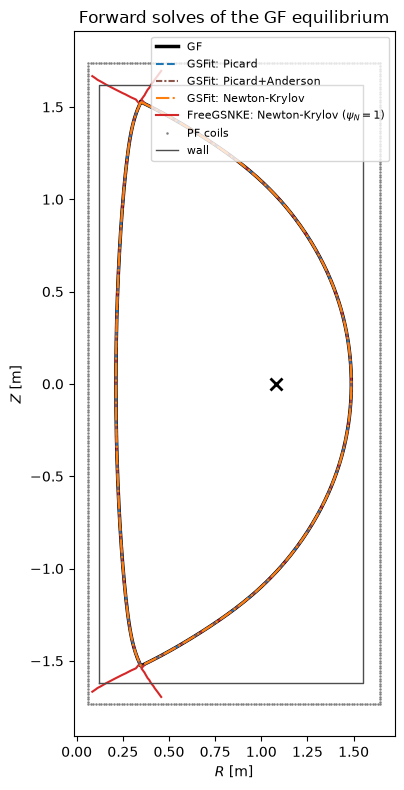

In [10]:
# --- The plasma boundaries: GF, FreeGSNKE and GSFit ---
freegsnke_psi = freegsnke_eq.psi()  # [weber / radian], shape (n_r, n_z)
freegsnke_psi_n = (freegsnke_psi - freegsnke_eq.psi_axis) / (freegsnke_eq.psi_bndry - freegsnke_eq.psi_axis)

fig, ax = plt.subplots(figsize=(6, 8))
ax.plot(gf_boundary_r, gf_boundary_z, color="black", lw=2.5, label="GF")
# psi_N = 1 on the whole grid, which for a diverted plasma includes the separatrix legs
ax.contour(freegsnke_eq.R, freegsnke_eq.Z, freegsnke_psi_n, levels=[1.0], colors="tab:red", linewidths=1.5, linestyles="solid")
for label, ids, colour, linestyle in [
    ("GSFit: Picard", gsfit_picard_with_axis_ids, "tab:blue", "--"),
    # ("GSFit: Picard, without axis", gsfit_picard_without_axis_ids, "tab:green", ":"),
    ("GSFit: Picard+Anderson", gsfit_picard_anderson_with_axis_ids, "tab:brown", (0, (3, 1, 1, 1))),
    ("GSFit: Newton-Krylov", gsfit_newton_krylov_ids, "tab:orange", "-."),
    # Newton-Picard is not plotted
    # ("GSFit: Newton-Picard", gsfit_newton_picard_ids, "tab:purple", (0, (5, 1))),
]:
    if ids.get(ep.time_slice[0].convergence.result.name) != "converged":
        continue
    ax.plot(ids.get(ep.time_slice[0].boundary.outline.r), ids.get(ep.time_slice[0].boundary.outline.z), color=colour, ls=linestyle, lw=1.5, label=label)
ax.plot([], [], color="tab:red", lw=1.5, label="FreeGSNKE: Newton-Krylov ($\\psi_N = 1$)")
ax.plot(coil_r, coil_z, "o", color="0.5", ms=0.8, label="PF coils")
ax.plot(limiter_r, limiter_z, color="0.3", lw=1.0, label="wall")
ax.plot(gf_mag_r, gf_mag_z, "x", color="black", ms=8, mew=2)
ax.set_aspect("equal")
ax.set_xlabel("$R$ [m]")
ax.set_ylabel("$Z$ [m]")
ax.set_title("Forward solves of the GF equilibrium")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()

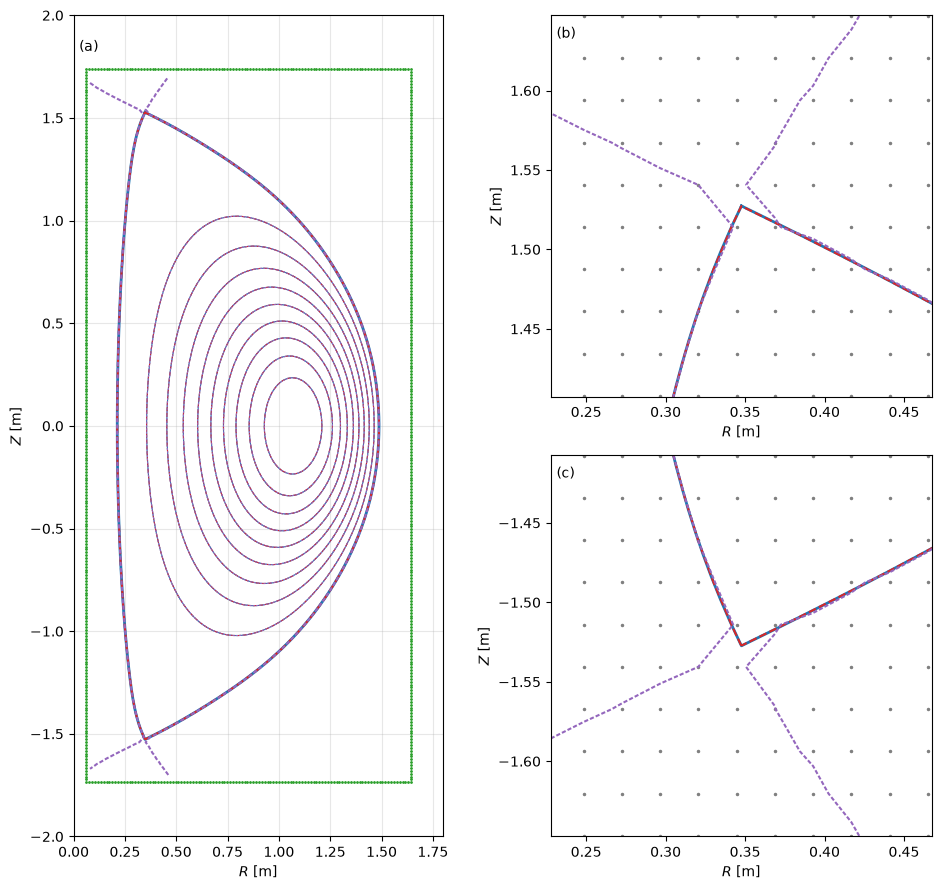

In [17]:
# --- The plasma boundaries, zoomed in on the X-points, with GSFit's grid ---
# (a): the whole plasma, and all the PF coils. (b) and (c): zoomed in on the upper and lower X-points, with the grid points GSFit solves on as dots.
# GF's and GSFit's boundaries are the outlines traced by each code; FreeGSNKE's is the psi_N = 1 contour of its flux, which for a diverted
# plasma includes the separatrix legs. (a) also has the flux surfaces at psi_N = 0.1, 0.2, ..., 0.9, the same levels for all three codes.
# psi_N is normalised by each code's own flux on the axis and at the boundary, so that the surfaces can be compared.
# All the GSFit runs converge to the same equilibrium, so only the Picard run is shown. The PF coils are the dots on the GF grid's boundary.
# Colours are from matplotlib's default cycle: GF blue, GSFit red (dashed), PF coils green, FreeGSNKE purple (finely dashed).
freegsnke_linestyle = (0, (2, 1))  # dashes 2 line widths long, with gaps of 1
gsfit_boundary_r = gsfit_picard_with_axis_ids.get(ep.time_slice[0].boundary.outline.r)  # [metre]
gsfit_boundary_z = gsfit_picard_with_axis_ids.get(ep.time_slice[0].boundary.outline.z)  # [metre]
gsfit_grid_r = gsfit_picard_with_axis_ids.get(ep.time_slice[0].profiles_2d[0].grid.dim1)  # [metre]
gsfit_grid_z = gsfit_picard_with_axis_ids.get(ep.time_slice[0].profiles_2d[0].grid.dim2)  # [metre]
gsfit_mesh_r, gsfit_mesh_z = np.meshgrid(gsfit_grid_r, gsfit_grid_z)

# The normalised flux, psi_N, on each code's grid
gf_mesh_r = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].r)  # [metre], shape (n_z, n_r)
gf_mesh_z = gf_equilibrium_ids.get(ep.time_slice[0].profiles_2d[0].z)  # [metre], shape (n_z, n_r)
gf_psi_n = (gf_psi - gf_psi_axis) / (gf_psi_boundary - gf_psi_axis)  # [dimensionless], shape (n_z, n_r)
gsfit_psi = gsfit_picard_with_axis_ids.get(ep.time_slice[0].profiles_2d[0].psi)  # [weber], shape (n_z, n_r)
gsfit_psi_axis = gsfit_picard_with_axis_ids.get(ep.time_slice[0].global_quantities.psi_magnetic_axis)  # [weber]
gsfit_psi_boundary = gsfit_picard_with_axis_ids.get(ep.time_slice[0].boundary.psi)  # [weber]
gsfit_psi_n = (gsfit_psi - gsfit_psi_axis) / (gsfit_psi_boundary - gsfit_psi_axis)  # [dimensionless], shape (n_z, n_r)
freegsnke_psi = freegsnke_eq.psi()  # [weber / radian], shape (n_r, n_z)
freegsnke_psi_n = (freegsnke_psi - freegsnke_eq.psi_axis) / (freegsnke_eq.psi_bndry - freegsnke_eq.psi_axis)
psi_n_flux_surfaces = np.linspace(0.1, 0.9, 9)  # [dimensionless]

# GF's boundary passes through its X-points, so they are its highest and lowest points
i_upper_x_point = np.argmax(gf_boundary_z)
i_lower_x_point = np.argmin(gf_boundary_z)
zoom_half_width = 0.12  # [metre]

fig, axes = plt.subplot_mosaic([["full", "upper"], ["full", "lower"]], figsize=(10, 9), width_ratios=[0.9, 1.0])
for ax in axes.values():
    ax.plot(gf_boundary_r, gf_boundary_z, color="tab:blue", lw=2.0)
    ax.plot(gsfit_boundary_r, gsfit_boundary_z, color="tab:red", ls="--", lw=1.5)
    ax.contour(freegsnke_eq.R, freegsnke_eq.Z, freegsnke_psi_n, levels=[1.0], colors="tab:purple", linewidths=1.5, linestyles=[freegsnke_linestyle])
    ax.plot(coil_r, coil_z, ".", color="tab:green", ms=2)
    ax.set_aspect("equal")
    ax.set_xlabel("$R$ [m]")
    ax.set_ylabel("$Z$ [m]")

# (a): the whole plasma and all the PF coils, with the flux surfaces
axes["full"].contour(gf_mesh_r, gf_mesh_z, gf_psi_n, levels=psi_n_flux_surfaces, colors="tab:blue", linewidths=0.8)
axes["full"].contour(gsfit_mesh_r, gsfit_mesh_z, gsfit_psi_n, levels=psi_n_flux_surfaces, colors="tab:red", linewidths=0.8, linestyles="dashed")
axes["full"].contour(
    freegsnke_eq.R, freegsnke_eq.Z, freegsnke_psi_n, levels=psi_n_flux_surfaces, colors="tab:purple", linewidths=0.8, linestyles=[freegsnke_linestyle]
)
axes["full"].set_xlim(0.0, 1.8)
axes["full"].set_ylim(-2.0, 2.0)
axes["full"].grid(True, alpha=0.3)

# (b) and (c): the X-points, with GSFit's grid points
for name, i_x_point in [("upper", i_upper_x_point), ("lower", i_lower_x_point)]:
    x_point_r = gf_boundary_r[i_x_point]  # [metre]
    x_point_z = gf_boundary_z[i_x_point]  # [metre]
    axes[name].plot(gsfit_mesh_r.ravel(), gsfit_mesh_z.ravel(), ".", color="0.5", ms=3, zorder=0)
    axes[name].set_xlim(x_point_r - zoom_half_width, x_point_r + zoom_half_width)
    axes[name].set_ylim(x_point_z - zoom_half_width, x_point_z + zoom_half_width)

# Label the panels (a) to (c), in their top left corners
for name, panel_label in [("full", "(a)"), ("upper", "(b)"), ("lower", "(c)")]:
    axes[name].text(0.015, 0.97, panel_label, transform=axes[name].transAxes, ha="left", va="top", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0})

fig.tight_layout()
plt.show()

fig.savefig("gf_gsfit_freegsnke.pdf")

In [12]:
# --- energy_mhd after every iteration, by re-running each solve and stopping it after 1, 2, 3, ... iterations ---
# GSFit is made to stop after k iterations by making it "converge" there: an enormous tolerance, so that the test always passes, with
# n_iter_min = k - 1, as the test is only allowed to pass once the iteration index exceeds n_iter_min. Stopping at n_iter_max instead would
# mark the solve as failed and discard the solution. A converged solve is post-processed, which calculates energy_mhd.
# Newton-Krylov and Newton-Picard stopped this way hand back one Picard update on from their current iterate, which is also what they hand
# back when they converge.
# FreeGSNKE is stopped after k iterations with `max_solving_iterations`; if an earlier iterate had a smaller residual it hands back that one.
# Each stopped run also records how many flux evaluations it took: GSFit's `convergence/flux_evaluations_n`, and FreeGSNKE's calls to
# `F_function`.
import time as time_py

tolerance_always_passes = 1.0e10

# FreeGSNKE: as many iterations as it took to converge above
tic = time_py.time()
freegsnke_energy_mhd_by_iter = np.full(freegsnke_n_iter, np.nan)  # [joule]
freegsnke_flux_evaluations_by_iter = np.full(freegsnke_n_iter, np.nan)
for i_iter in range(freegsnke_n_iter):
    eq, profiles, solver, n_flux_evaluations = solve_freegsnke_forward(max_solving_iterations=i_iter + 1, target_relative_tolerance=1.0e-9)
    freegsnke_energy_mhd_by_iter[i_iter] = freegsnke_energy_mhd(eq, profiles)
    freegsnke_flux_evaluations_by_iter[i_iter] = n_flux_evaluations
print(f"FreeGSNKE: {freegsnke_n_iter} re-runs in {time_py.time() - tic:.0f} s")

# GSFit: each run is re-run up to `n_iter` iterations, stopping at its first failure
gsfit_energy_mhd_by_iter = {}  # [joule], by run
gsfit_flux_evaluations_by_iter = {}  # by run
for name, nonlinear_solver_method, supply_magnetic_axis, apply_anderson_mixing, n_iter in [
    # As many iterations as it took to converge above
    ("GSFit: Picard", "picard", True, False, gsfit_picard_with_axis_ids.get(ep.time_slice[0].convergence.iterations_n)),
    # Commented out, like its full solve above
    # ("GSFit: Picard, without axis", "picard", False, False, gsfit_n_iter_max),
    ("GSFit: Picard+Anderson", "picard", True, True, gsfit_picard_anderson_with_axis_ids.get(ep.time_slice[0].convergence.iterations_n)),
    # 25 iterations, carrying on past convergence, to match FreeGSNKE
    ("GSFit: Newton-Krylov", "newton_krylov", False, False, 25),
    # Newton-Picard is not plotted, so is not re-run
    # ("GSFit: Newton-Picard", "newton_picard", False, False, 25),
]:
    tic = time_py.time()
    energy_mhd_by_iter = np.full(n_iter, np.nan)
    flux_evaluations_by_iter = np.full(n_iter, np.nan)
    for i_iter in range(n_iter):
        ids = solve_gsfit_forward(
            nonlinear_solver_method, supply_magnetic_axis, apply_anderson_mixing, i_iter, i_iter + 2, tolerance_always_passes
        ).equilibrium_ids
        if ids.get(ep.time_slice[0].convergence.result.name) != "converged":
            print(f"{name}: failed at iteration {i_iter + 1}: {ids.get(ep.time_slice[0].convergence.result.description)}")
            break
        energy_mhd_by_iter[i_iter] = ids.get(ep.time_slice[0].global_quantities.energy_mhd)
        flux_evaluations_by_iter[i_iter] = ids.get(ep.time_slice[0].convergence.flux_evaluations_n)
    gsfit_energy_mhd_by_iter[name] = energy_mhd_by_iter
    gsfit_flux_evaluations_by_iter[name] = flux_evaluations_by_iter
    print(f"{name}: {i_iter + 1} re-runs in {time_py.time() - tic:.0f} s")

FreeGSNKE: 15 re-runs in 26 s


KeyboardInterrupt: 

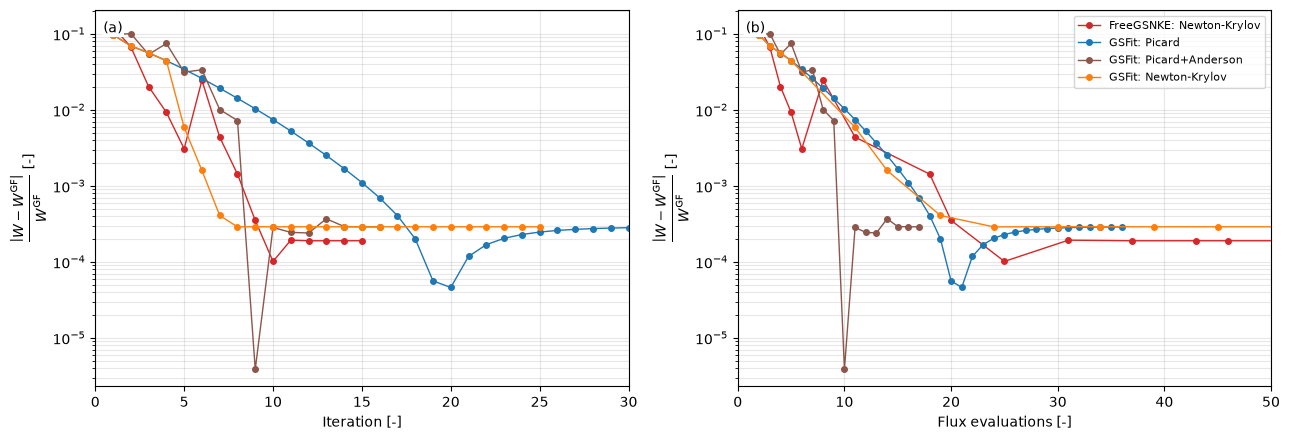

In [ ]:
# --- Convergence of energy_mhd ---
# The relative error of energy_mhd against GF, on a log scale. (a): against iteration, up to 30 iterations. (b): against flux evaluations,
# up to 50: the calculations of the flux on the grid from the current density, which is where nearly all the time goes: a Picard
# iteration does one, a Newton iteration several. GSFit's is a Greens-function sum followed by the search for the magnetic axis and the
# boundary, FreeGSNKE's a linear Grad-Shafranov solve: the same role, but not the same cost. The error levels off at the forward solves'
# discretisation error, as their grid is coarser than GF's, and it dips if a run crosses GF's value.
energy_mhd_by_iter = {"FreeGSNKE: Newton-Krylov": freegsnke_energy_mhd_by_iter} | gsfit_energy_mhd_by_iter  # [joule]
flux_evaluations_by_iter = {"FreeGSNKE: Newton-Krylov": freegsnke_flux_evaluations_by_iter} | gsfit_flux_evaluations_by_iter
styles = {
    "FreeGSNKE: Newton-Krylov": {"color": "tab:red", "marker": "o"},
    "GSFit: Picard": {"color": "tab:blue", "marker": "o"},
    # "GSFit: Picard, without axis": {"color": "tab:green", "marker": "o"},
    "GSFit: Picard+Anderson": {"color": "tab:brown", "marker": "o"},
    "GSFit: Newton-Krylov": {"color": "tab:orange", "marker": "o"},
    # "GSFit: Newton-Picard": {"color": "tab:purple", "marker": "o"},
}

fig, (ax_error_iteration, ax_error_evaluations) = plt.subplots(1, 2, figsize=(13, 4.5))
for name, energy_mhd in energy_mhd_by_iter.items():
    iteration = np.arange(1, energy_mhd.size + 1)
    flux_evaluations = flux_evaluations_by_iter[name]
    energy_mhd_relative_error = np.abs(energy_mhd - gf_energy_mhd) / gf_energy_mhd  # [dimensionless]
    ax_error_iteration.semilogy(iteration, energy_mhd_relative_error, ms=4, lw=1.0, label=name, **styles[name])
    ax_error_evaluations.semilogy(flux_evaluations, energy_mhd_relative_error, ms=4, lw=1.0, label=name, **styles[name])

ax_error_iteration.set_xlabel("Iteration [-]")
ax_error_iteration.set_xlim([0.0, 30.0])
ax_error_iteration.set_ylabel(r"$\dfrac{\left|W - W^\mathrm{GF}\right|}{W^\mathrm{GF}}$ [-]")
ax_error_iteration.grid(True, which="both", alpha=0.3)

ax_error_evaluations.set_xlabel("Flux evaluations [-]")
ax_error_evaluations.set_xlim([0.0, 50.0])
ax_error_evaluations.set_ylabel(r"$\dfrac{\left|W - W^\mathrm{GF}\right|}{W^\mathrm{GF}}$ [-]")
ax_error_evaluations.grid(True, which="both", alpha=0.3)
ax_error_evaluations.legend(fontsize=8)

# Label the panels (a) and (b), in their top left corners
for ax, panel_label in [
    (ax_error_iteration, "(a)"),
    (ax_error_evaluations, "(b)"),
]:
    ax.text(0.015, 0.97, panel_label, transform=ax.transAxes, ha="left", va="top", bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.0})

fig.tight_layout()
plt.show()

fig.savefig("gsfit_convergence_fixed_boundary.pdf")